# 2. Roughness - 2D

In [1]:
import numpy as np
import pandas as pd
import os

from surface_functions_2D import compute_surface_variance, compute_surface_roughness

Organization of this notebook:
1) We open sequentially each dataframe (per noise type, per delta).
2) The roughness corresponding to each simulation is computed from the phases. Then they are added as a new column to the corresponding dataframe. There are two variants:
    1. The variance between the heights.
    2. The square root of the variance between the heights.
3) Then, the average roughness is computed, grouping by K, L. The two versions are computed (the square root of the average of 2.1., and the simple average of 2.). The result is stored in the summary_rows list.
4) This information is then saved on an AverageSims array, containing all the simulations per noise type, delta, K, L. 

The difference between 2.1 and 2.2 is the order between taking the square root and averaging over simulations (which do not commute, since $\langle x^{1/2}\rangle - \langle x\rangle^{1/2} \neq 0$). However in practice the exponents do not see that difference.

## Dataframe computations

In [2]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_2D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        roughness_list = []  # used to compute per-sim roughness
        variance_list = []   # used to compute per-sim variance
        datapoint_list = []

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            variance = np.asarray(compute_surface_variance(phases), dtype=float)
            roughness = np.asarray(compute_surface_roughness(phases), dtype=float)

            variance_list.append(variance)
            roughness_list.append(roughness)
            datapoint_list.append(len(roughness))

        # Avoid chained-assignment issues
        df = df.copy()
        df["variance"] = variance_list
        df["roughness"] = roughness_list
        df["datapoints"] = datapoint_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE ROUGHNESS PER (K, L, T) ##
        # group by K, L, T and compute mean roughness for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):

            rough_arrays = [np.asarray(r, dtype=float) for r in group["roughness"]]
            mean_roughness = np.mean(np.stack(rough_arrays, axis=0), axis=0)

            variance_arrays = [np.asarray(r, dtype=float) for r in group["variance"]]
            mean_roughness2 = np.sqrt(np.mean(np.stack(variance_arrays, axis=0), axis=0))

            # assume all t are identical within group; take the first
            t = group.iloc[0]["t"]
            seed_list = group.index.tolist()
            M = len(seed_list) 

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{M}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "typenoise": typenoise,
                    "delta": delta,
                    "deltaname": deltaname,
                    "K": K_val,
                    "L": L_val,
                    "t": t,
                    "M": M,
                    "T": T_val,
                    "mean_roughness": mean_roughness,
                    "mean_roughness2": mean_roughness2,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [3]:
# Note: we start from scratch the average DataFrame (each time this code is run)
avg_df = pd.DataFrame()
avg_df_path = "../Simulations_2D/average_simulations.pkl"

# Build/update AverageSims dataframe
if summary_rows:
    new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
    if avg_df.empty:
        avg_df = new_avg
    else:
        # ensure we have an index; if not, give it one
        if avg_df.index.name is None:
            avg_df = avg_df.copy()
            avg_df.index.name = "avg_id"
        avg_df = pd.concat([avg_df, new_avg])
        # keep last occurrence per avg_id
        avg_df = avg_df[~avg_df.index.duplicated(keep="last")]

    avg_df.to_pickle(avg_df_path)
    print(f"Saved average simulations ({len(df)}) to:", avg_df_path)

Saved average simulations (148) to: ../Simulations_2D/average_simulations.pkl


In [4]:
avg_df

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2
avg_id,,,,,,,,,,
TimeDep_delta0_L125_K1.0_T20000_M103,TimeDep,0.000000,0,1.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",103,20000,"[0.0, 0.04340444523640393, 0.04561091348993716...","[0.0, 0.0434057168538711, 0.045612627702051, 0..."
TimeDep_delta0_L250_K1.0_T20000_M30,TimeDep,0.000000,0,1.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",30,20000,"[0.0, 0.04345658333301187, 0.04568980752160003...","[0.0, 0.04345687326238199, 0.04569022603499072..."
TimeDep_delta0_L500_K1.0_T20000_M7,TimeDep,0.000000,0,1.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",7,20000,"[0.0, 0.043430455762653156, 0.0456677743264955...","[0.0, 0.043430477034302715, 0.0456679473138036..."
TimeDep_delta0_L1000_K1.0_T20000_M1,TimeDep,0.000000,0,1.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1,20000,"[0.0, 0.043480720390408865, 0.0456108179558477...","[0.0, 0.043480720390408865, 0.0456108179558477..."
TimeDep_deltaatan5_L125_K1.0_T20000_M52,TimeDep,1.373401,atan5,1.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",52,20000,"[0.0, 0.0743784241900767, 0.08352853556779778,...","[0.0, 0.0743793573293762, 0.08352992285463373,..."
TimeDep_deltaatan5_L250_K1.0_T20000_M14,TimeDep,1.373401,atan5,1.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",14,20000,"[0.0, 0.07439739169913463, 0.08344000411442086...","[0.0, 0.0743981205101762, 0.08344055500584736,..."
TimeDep_deltaatan5_L500_K1.0_T20000_M2,TimeDep,1.373401,atan5,1.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",2,20000,"[0.0, 0.07440215624362806, 0.08337733875157055...","[0.0, 0.07440217686978567, 0.08337742467913258..."
Columnar_delta0_L125_K40.0_T20000_M109,Columnar,0.000000,0,40.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",109,20000,"[0.0, 0.781406776278394, 0.7955206701989574, 0...","[0.0, 0.781409821932389, 0.7955246206987788, 0..."
Columnar_delta0_L250_K40.0_T20000_M31,Columnar,0.000000,0,40.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",31,20000,"[0.0, 0.7814338545669108, 0.7956651743644104, ...","[0.0, 0.781434688360399, 0.7956663072294541, 0..."


In [5]:
avg_df[(avg_df["K"] == 40) & (avg_df["T"] == 20000)]

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2
avg_id,,,,,,,,,,
Columnar_delta0_L125_K40.0_T20000_M109,Columnar,0.000000,0,40.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",109,20000,"[0.0, 0.781406776278394, 0.7955206701989574, 0...","[0.0, 0.781409821932389, 0.7955246206987788, 0..."
Columnar_delta0_L250_K40.0_T20000_M31,Columnar,0.000000,0,40.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",31,20000,"[0.0, 0.7814338545669108, 0.7956651743644104, ...","[0.0, 0.781434688360399, 0.7956663072294541, 0..."
Columnar_delta0_L500_K40.0_T20000_M7,Columnar,0.000000,0,40.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",7,20000,"[0.0, 0.7814385726312738, 0.7955799251344224, ...","[0.0, 0.7814387373648426, 0.7955801611938776, ..."
Columnar_delta0_L1000_K40.0_T20000_M1,Columnar,0.000000,0,40.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1,20000,"[0.0, 0.7813916115534549, 0.7955376087930128, ...","[0.0, 0.7813916115534549, 0.7955376087930128, ..."
Columnar_deltaatan5_L125_K40.0_T20000_M109,Columnar,1.373401,atan5,40.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",109,20000,"[0.0, 0.07100208848346541, 0.08947940455821764...","[0.0, 0.07103216137509313, 0.08954502048415135..."
Columnar_deltaatan5_L250_K40.0_T20000_M31,Columnar,1.373401,atan5,40.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",31,20000,"[0.0, 0.07103684030581711, 0.08967367725094032...","[0.0, 0.0710420526201468, 0.08968473964951984,..."
Columnar_deltaatan5_L500_K40.0_T20000_M7,Columnar,1.373401,atan5,40.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",7,20000,"[0.0, 0.07076610169812321, 0.08912988887732717...","[0.0, 0.07076699869733796, 0.08913098609633945..."
Columnar_deltaatan5_L1000_K40.0_T20000_M1,Columnar,1.373401,atan5,40.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1,20000,"[0.0, 0.07121714513644721, 0.08990563036510325...","[0.0, 0.07121714513644721, 0.08990563036510325..."


In [6]:
avg_df.describe()

,delta,K,L,M,T
count,15.000000,15.000000,15.000000,15.000000,15.0
mean,0.640920,21.800000,433.333333,33.666667,20000.0
std,0.709221,20.139513,326.871899,40.747772,0.0
min,0.000000,1.000000,125.000000,1.000000,20000.0
25%,0.000000,1.000000,187.500000,4.500000,20000.0
50%,0.000000,40.000000,250.000000,14.000000,20000.0
75%,1.373401,40.000000,500.000000,41.500000,20000.0
max,1.373401,40.000000,1000.000000,109.000000,20000.0


## Inspection of the computed quantities

In [8]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

%load_ext autoreload
%autoreload 2

from plotting_helpers_evolution import plot_roughness_evolution
from plotting_helpers_collapse import plot_roughness_collapse

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
avg_df_path = "../Simulations_2D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

In [10]:
T = 20000
Ks = [1, 40]

### Large coupling = KPZ, EW

In [14]:
# Adjustment to the crossover time: t_x = tx * L**z (BY HAND for Ks=[1,40])
tx = {"TimeDep": {"EW": 1/100, "KPZ": 1/10}, "Columnar": {"EW": 1/1500, "KPZ": 1/80}}

# TimeDep
## 0
## atan5
# Columnar
## 0
## atan5


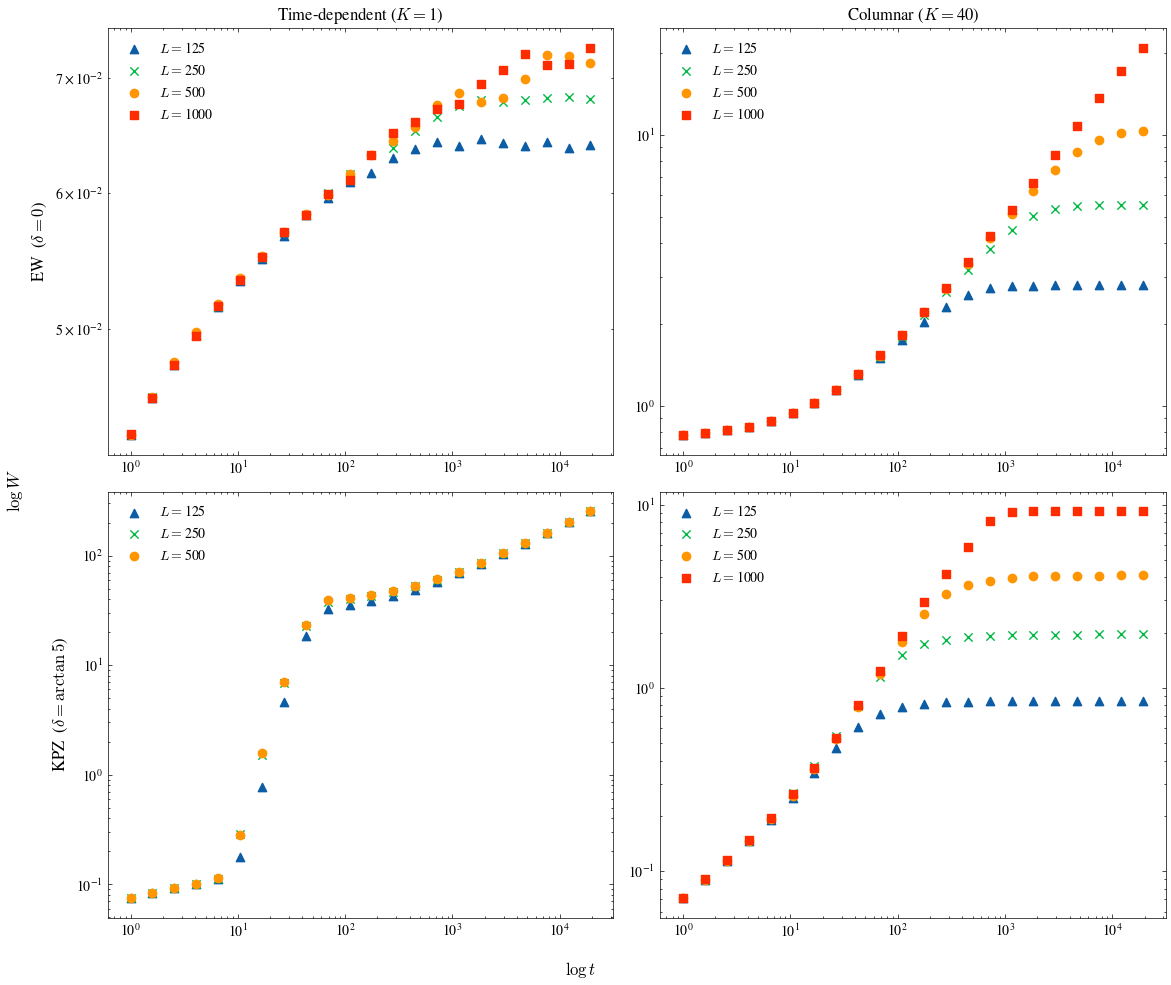

In [17]:
plot_roughness_evolution(avg_df, T, tx, Ks=Ks)

In [33]:
(t[1],t[2]),(t[9],t[10]),(t[-2],t[-1])

((np.float64(1.00000050000025), np.float64(1.6000008000004002)),
 (np.float64(42.94002147001074), np.float64(68.71003435501719)),
 (np.float64(12089.256044628024), np.float64(19342.819671409838)))

In [39]:
for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
):
    print("#", typenoise)
    for j, (delta, deltaname, nameeq) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"], ["EW","KPZ"])):

        print("##", nameeq, "( δ =",deltaname,")")
        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["deltaname"] == deltaname)
            & (avg_df["T"] == T)
            & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            # & (avg_df["L"] < 1000)
        )
        sub_df = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub_df.iterrows():
            t = row["t"]
            mean_roughness = row["mean_roughness"]
            L = row["L"]
            K = row["K"]
        
            if L == 500:
                print("-- loglog Slopes --")
                slope_initial = np.log(mean_roughness[2]) - np.log(mean_roughness[1])
                slope_initial /= (np.log(t[2]) - np.log(t[1]))
                slope_medium = np.log(mean_roughness[10]) - np.log(mean_roughness[9])
                slope_medium /= (np.log(t[10]) - np.log(t[9]))
                slope_final = np.log(mean_roughness[-2]) - np.log(mean_roughness[-1])
                slope_final /= (np.log(t[-2]) - np.log(t[-1]))
                print("β =",np.round(slope_initial,2), np.round(slope_medium,2), np.round(slope_final,2))
                print()
                    

# TimeDep
## EW ( δ = 0 )
-- loglog Slopes --
β = 0.11 0.05 -0.02

## KPZ ( δ = atan5 )
-- loglog Slopes --
β = 0.24 1.13 0.48

# Columnar
## EW ( δ = 0 )
-- loglog Slopes --
β = 0.04 0.34 0.04

## KPZ ( δ = atan5 )
-- loglog Slopes --
β = 0.49 0.89 0.01



# TimeDep
## 0
## atan5
# Columnar
## 0
## atan5


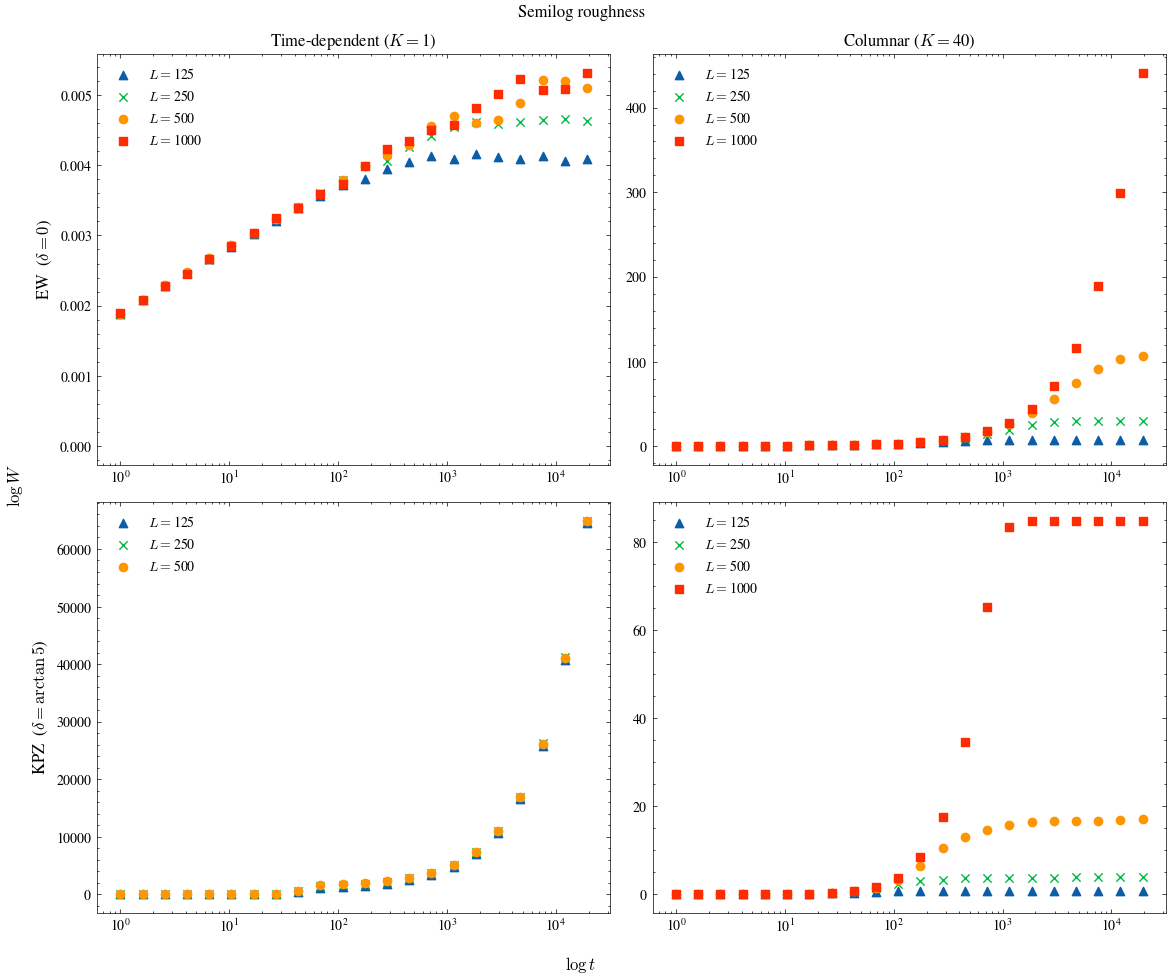

In [62]:
fig, ax = plt.subplots(2, 2, figsize=(12,10))
fig.suptitle("Semilog roughness")

fig.supxlabel(r"$\log t$")
fig.supylabel(r"$\log W$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
):
    print("#", typenoise)
    for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

        print("##", deltaname)
        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["deltaname"] == deltaname)
            & (avg_df["T"] == T)
            & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            # & (avg_df["L"] < 1000)
        )
        sub_df = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub_df.iterrows():
            t = row["t"]
            mean_roughness = row["mean_roughness"]
            L = row["L"]
            K = row["K"]
                    
            ax[j,i].scatter(t, mean_roughness**2, label=r"$L=$" + str(L), marker=markerdict[L])

        ax[j,i].set_xscale('log')
        # ax[j,i].set_yscale('log')
        
    # Scalings
    #ax[0,0].semilogx(t[1:-5:], 0.0022 + np.log(t[1:-5:])/2600, linestyle="--", color="k")

ax[0,0].set_title(f"Time-dependent ($K=${Ks[0]})")
ax[0,1].set_title(f"Columnar ($K=${Ks[1]})")      
ax[0,0].set_ylabel(r"EW  ($\delta=0$)", fontsize=12)
ax[1,0].set_ylabel(r"KPZ  ($\delta=\arctan5$)", fontsize=12)

ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()

plt.tight_layout()
plt.show()

#### Family-Vicsek collapse

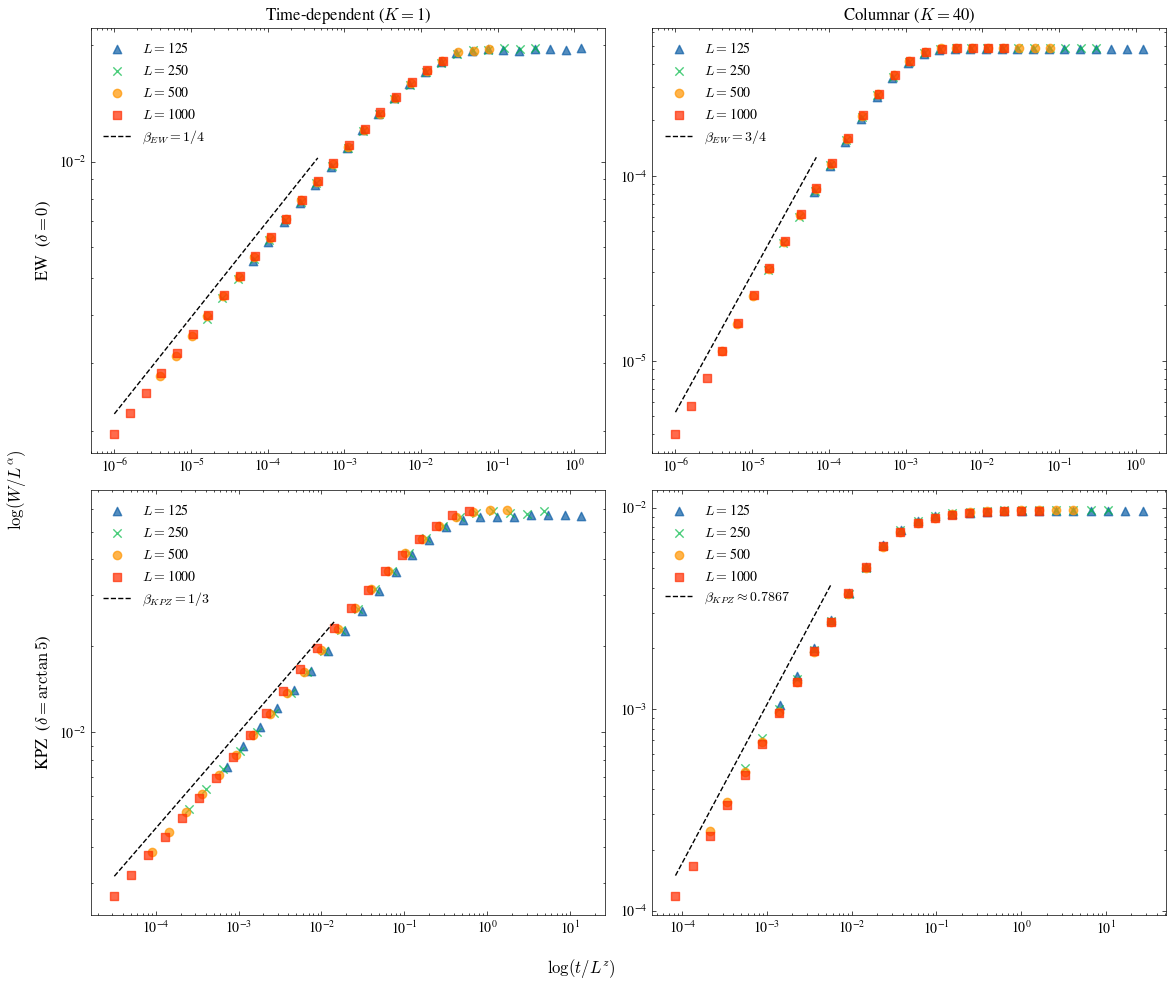

In [7]:
plot_roughness_collapse(avg_df, T, tx, Ks=Ks)

### Small coupling = Random deposition

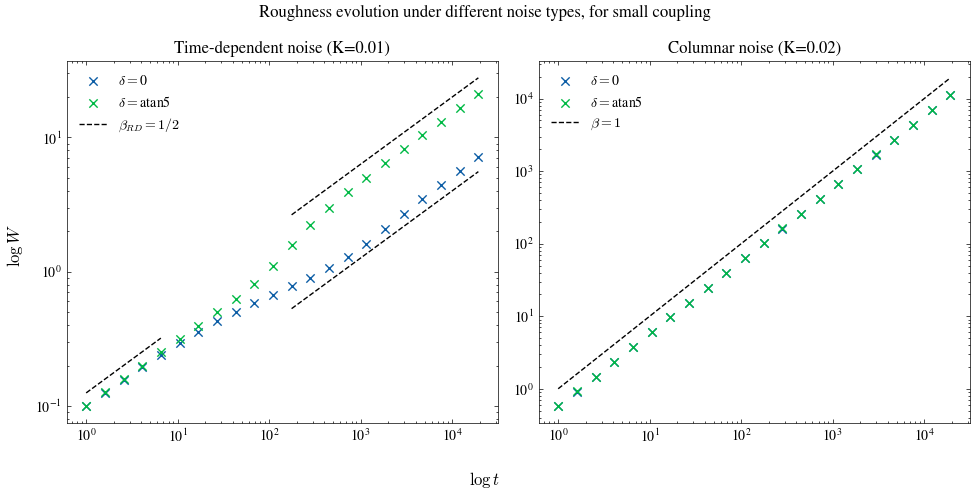

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle("Roughness evolution under different noise types, for small coupling")

fig.supxlabel(r"$\log t$")
fig.supylabel(r"$\log W$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
):

    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == 0.01) | (avg_df["K"] == 0.02))
        )
        sub = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub.iterrows():
            t = row["t"]
            mean_roughness = row["mean_roughness"]
            L = row["L"]
            K = row["K"]
            M = row["M"]

            ax[i].scatter(t, mean_roughness, label=r"$\delta=$" + deltaname, marker=markerdict[L])
            ax[i].set_title(typelabel+ f" (K={K})")

        ax[i].set_yscale('log')
        ax[i].set_xscale('log')

ax[0].loglog(t[12::], t[12::]**(1/2) /5, label=r"$\beta_{RD}=1/2$", linestyle="--", color="k")
ax[0].loglog(t[12::], t[12::]**(1/2) /25, linestyle="--", color="k")
ax[0].loglog(t[1:6:], t[1:6:]**(1/2) /8, linestyle="--", color="k")

ax[1].loglog(t[1::], t[1::]**(1), label=r"$\beta=1$", linestyle="--", color="k")

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()